In [102]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/burnout/train.csv")

df.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [103]:
df.isna().sum()

Employee ID                0
Date of Joining            0
Gender                     0
Company Type               0
WFH Setup Available        0
Designation                0
Resource Allocation     1381
Mental Fatigue Score    2117
Burn Rate               1124
dtype: int64

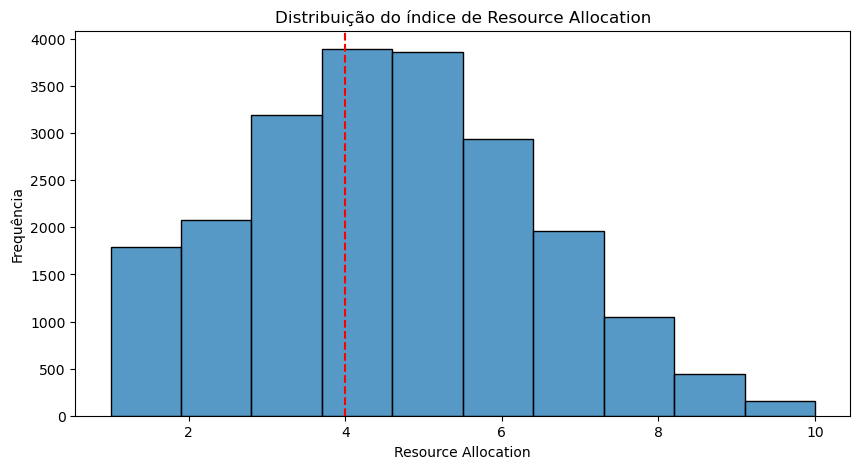

In [104]:
plt.figure(figsize=(10,5))

sns.histplot(data=df["Resource Allocation"], bins=10)
plt.title("Distribuição do índice de Resource Allocation")
plt.xlabel("Resource Allocation")
plt.ylabel("Frequência")

plt.axvline(x=df["Resource Allocation"].median(), color='red', linestyle='--', label="Mediana do resource allocation")

plt.show()

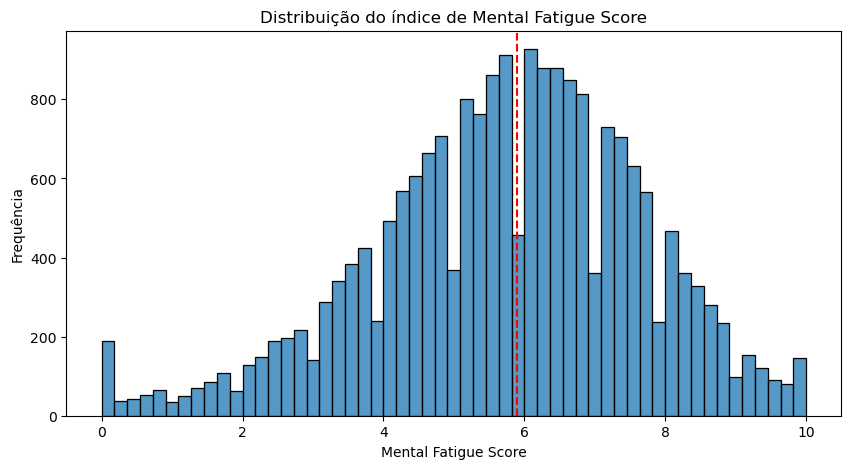

In [105]:
plt.figure(figsize=(10,5))

sns.histplot(data=df["Mental Fatigue Score"])
plt.title("Distribuição do índice de Mental Fatigue Score")
plt.xlabel("Mental Fatigue Score")
plt.ylabel("Frequência")

plt.axvline(x=df["Mental Fatigue Score"].median(), color='red', linestyle='--', label="Mediana do índice")

plt.show()

In [106]:
# Avaliando o tempo de empresa em dias a partir do dia que a pessoa entrou na empresa
df["company time"] = (pd.to_datetime('today') - pd.to_datetime(df["Date of Joining"])).dt.days

In [107]:
# Substituindo pela mediana os valores faltantes em Mental Fatigue Score e Resource Allocation
df["Resource Allocation"] = df["Resource Allocation"].fillna(value=df["Resource Allocation"].median())
df["Mental Fatigue Score"] = df["Mental Fatigue Score"].fillna(value=df["Mental Fatigue Score"].median())

In [108]:
# Dropando os valores em que não temos a label Burn Rate
df.dropna(inplace=True)

In [109]:
df.drop(columns=["Employee ID", "Date of Joining"], inplace=True)

In [110]:
# Realizando a codificação de colunas para valores discretos
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
ohe = OneHotEncoder(sparse_output=False, dtype=int)

df["WFH Setup Available"] = le.fit_transform(df["WFH Setup Available"])

# Aplicando One Hot Encoding
colunas_ohe = ['Gender', 'Company Type']
matriz_ohe = ohe.fit_transform(df[colunas_ohe])

novos_nomes = ohe.get_feature_names_out(colunas_ohe)
df_ohe = pd.DataFrame(matriz_ohe, columns=novos_nomes, index=df.index)

df = pd.concat([df, df_ohe], axis=1).drop(columns=colunas_ohe)

In [111]:
df

,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,company time,Gender_Female,Gender_Male,Company Type_Product,Company Type_Service
0,0,2.0,3.0,3.8,0.16,6528,1,0,0,1
1,1,1.0,2.0,5.0,0.36,6467,0,1,0,1
2,1,2.0,4.0,5.8,0.49,6732,1,0,1,0
3,1,1.0,1.0,2.6,0.20,6494,0,1,0,1
4,0,3.0,7.0,6.9,0.52,6596,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...
22745,0,1.0,3.0,5.9,0.41,6437,1,0,0,1
22746,1,3.0,6.0,6.7,0.59,6783,1,0,1,0
22747,1,3.0,7.0,5.9,0.72,6492,0,1,0,1
22748,0,2.0,5.0,5.9,0.52,6792,1,0,0,1


### Inferência

In [112]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="Burn Rate", axis=1)
y = df["Burn Rate"]

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [113]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [114]:
print(f"Coefciente de determinação (R²): {model.score(X_train, Y_train):.2f}")

print(f'Intercepto: {model.intercept_:.2f}')

coeff_df = pd.DataFrame(model.coef_,X_train.columns,columns=['Coefficient'])
coeff_df

Coefciente de determinação (R²): 0.87
Intercepto: -0.13


,Coefficient
WFH Setup Available,-0.017033
Designation,0.008741
Resource Allocation,0.031312
Mental Fatigue Score,0.066982
company time,0.000007
Gender_Female,-0.003138
Gender_Male,0.003138
Company Type_Product,-0.000159
Company Type_Service,0.000159


In [115]:
y_pred = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print(f'MAE: {mean_absolute_error(Y_test, y_pred):.4f}')
print(f'MSE: {mean_squared_error(Y_test, y_pred):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(Y_test, y_pred)):.4f}')

MAE: 0.0535
MSE: 0.0050
RMSE: 0.0709


### Regularização: Ridge e Lasso

In [116]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, Y_train)
ridge_pred = ridge.predict(X_test)

print("=== RIDGE REGRESSION ===")
print(f'MAE: {mean_absolute_error(Y_test, ridge_pred):.4f}')
print(f'MSE: {mean_squared_error(Y_test, ridge_pred):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(Y_test, ridge_pred)):.4f}')
print(f'R² (train): {ridge.score(X_train, Y_train):.4f}')
print(f'R² (test): {ridge.score(X_test, Y_test):.4f}')


=== RIDGE REGRESSION ===
MAE: 0.0535
MSE: 0.0050
RMSE: 0.0709
R² (train): 0.8712
R² (test): 0.8679


In [117]:
# Lasso Regression
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, Y_train)
lasso_pred = lasso.predict(X_test)

print("\n=== LASSO REGRESSION ===")
print(f'MAE: {mean_absolute_error(Y_test, lasso_pred):.4f}')
print(f'MSE: {mean_squared_error(Y_test, lasso_pred):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(Y_test, lasso_pred)):.4f}')
print(f'R² (train): {lasso.score(X_train, Y_train):.4f}')
print(f'R² (test): {lasso.score(X_test, Y_test):.4f}')



=== LASSO REGRESSION ===
MAE: 0.0540
MSE: 0.0052
RMSE: 0.0721
R² (train): 0.8678
R² (test): 0.8637


In [118]:
# Features selecionadas pelo Lasso (coeficientes não nulos)
print("\n=== FEATURES SELECIONADAS PELO LASSO ===")
lasso_coef = pd.DataFrame({
    'Feature': X_train.columns,
    'Coeficiente': lasso.coef_
})
print(lasso_coef[lasso_coef['Coeficiente'] != 0].to_string(index=False))


=== FEATURES SELECIONADAS PELO LASSO ===
             Feature  Coeficiente
 Resource Allocation     0.035183
Mental Fatigue Score     0.065926
        company time     0.000006


In [119]:
# Comparação dos modelos
print("\n=== COMPARAÇÃO GERAL ===")
comparison_df = pd.DataFrame({
    'Modelo': ['Linear Regression', 'Ridge', 'Lasso'],
    'MAE': [
        mean_absolute_error(Y_test, y_pred),
        mean_absolute_error(Y_test, ridge_pred),
        mean_absolute_error(Y_test, lasso_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(Y_test, y_pred)),
        np.sqrt(mean_squared_error(Y_test, ridge_pred)),
        np.sqrt(mean_squared_error(Y_test, lasso_pred))
    ],
    'R² Test': [
        model.score(X_test, Y_test),
        ridge.score(X_test, Y_test),
        lasso.score(X_test, Y_test)
    ]
})
print(comparison_df.to_string(index=False))



=== COMPARAÇÃO GERAL ===
           Modelo      MAE    RMSE  R² Test
Linear Regression 0.053483 0.07094 0.867874
            Ridge 0.053483 0.07094 0.867874
            Lasso 0.053952 0.07205 0.863706
